In [2]:
import pandas as pd
df = pd.read_csv("Heart.csv")

In [3]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    int64  
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    object 
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    object 
 14  AHD         303 non-null    object 
dtypes: float64(2), int64(10), object(3)
memory usage: 35.6+ KB


In [5]:
df.isna().sum()

Unnamed: 0    0
Age           0
Sex           0
ChestPain     0
RestBP        0
Chol          0
Fbs           0
RestECG       0
MaxHR         0
ExAng         0
Oldpeak       0
Slope         0
Ca            4
Thal          2
AHD           0
dtype: int64

In [6]:

m=df["Ca"].mean()

In [7]:
df["Ca"].fillna(m,inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\3593772268.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Ca"].fillna(m,inplace=True)


In [8]:
m2=df["Thal"].value_counts()
m2[0]
df["Thal"].fillna(m2[0],inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\1651029708.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m2[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\1651029708.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["Thal"].fillna(m2[0],inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\1651029708.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [11]:
def find_outliers(df,col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.boxplot(df[col])
    plt.subplot(1,2,2)
    mean4=df[col].mean()
    std4=df[col].std() 
    sns.histplot(data=df , x=col , kde=True)
    plt.axvline(mean4,color="red")
    plt.axvline(mean4+3*std4 , color = "blue")
    plt.axvline(mean4-3*std4 , color="blue")

In [12]:
def show_outliers(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr = q3-q1
    upper = q3+(1.5*iqr)
    lower=q1-(1.5*iqr)
    return df[(df[col]<lower) | (df[col]>upper)]
    
    

In [13]:
def handleOutliers(df,col):
    q1=df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr=q3-q1
    lower = q1-(1.5*iqr)
    upper = q3+(1.5*iqr)
    df.loc[df[col]>upper , col]=upper
    df.loc[df[col]<lower , col]=lower

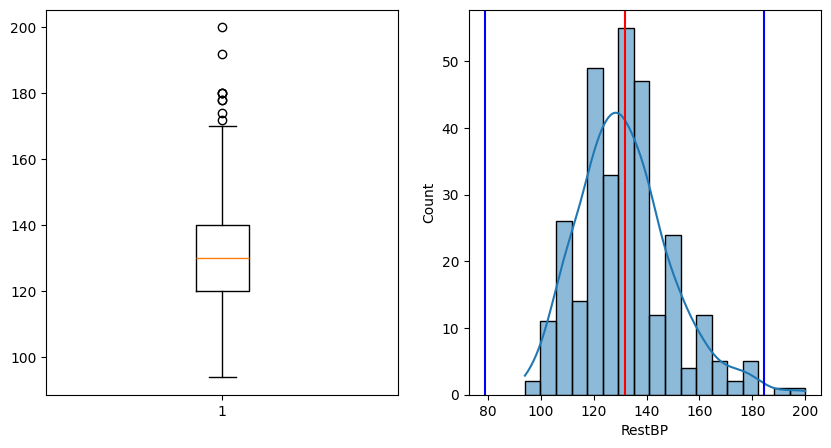

In [14]:
find_outliers(df,"RestBP")

In [15]:
show_outliers(df,"RestBP")

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
14,15,52,1,nonanginal,172,199,1,0,162,0,0.5,1,0.0,reversable,No
83,84,68,1,nonanginal,180,274,1,2,150,1,1.6,2,0.0,reversable,Yes
126,127,56,0,asymptomatic,200,288,1,2,133,1,4.0,3,2.0,reversable,Yes
172,173,59,0,asymptomatic,174,249,0,0,143,1,0.0,2,0.0,normal,Yes
183,184,59,1,typical,178,270,0,2,145,0,4.2,3,0.0,reversable,No
188,189,54,1,nontypical,192,283,0,2,195,0,0.0,1,1.0,reversable,Yes
201,202,64,0,asymptomatic,180,325,0,0,154,1,0.0,1,0.0,normal,No
213,214,66,0,asymptomatic,178,228,1,0,165,1,1.0,2,2.0,reversable,Yes
231,232,55,0,asymptomatic,180,327,0,1,117,1,3.4,2,0.0,normal,Yes


In [16]:
handleOutliers(df,"RestBP")

In [17]:
df["ChestPain"].unique()

array(['typical', 'asymptomatic', 'nonanginal', 'nontypical'],
      dtype=object)

In [18]:
df["ChestPain"] =  df["ChestPain"].replace({"typical":0, "asymptomatic":1, "nonanginal":2, "nontypical":3})

C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\2042994909.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ChestPain"] =  df["ChestPain"].replace({"typical":0, "asymptomatic":1, "nonanginal":2, "nontypical":3})


In [19]:
df["Thal"].unique()

array(['fixed', 'normal', 'reversable', np.int64(166)], dtype=object)

In [20]:
df["Thal"] = df["Thal"].replace({'fixed':0, 'normal':1, 'reversable':2})

C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\4014924376.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Thal"] = df["Thal"].replace({'fixed':0, 'normal':1, 'reversable':2})


In [21]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,0,145,233,1,2,150,0,2.3,3,0.0,0,No
1,2,67,1,1,160,286,0,2,108,1,1.5,2,3.0,1,Yes
2,3,67,1,1,120,229,0,2,129,1,2.6,2,2.0,2,Yes
3,4,37,1,2,130,250,0,0,187,0,3.5,3,0.0,1,No
4,5,41,0,3,130,204,0,2,172,0,1.4,1,0.0,1,No


In [22]:
df["AHD"].value_counts()

AHD
No     164
Yes    139
Name: count, dtype: int64

In [23]:
x=df.drop(["Unnamed: 0" , "AHD"], axis =1)
y=df["AHD"]

In [24]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
x_ss = ss.fit_transform(x)

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test , y_train,y_test = train_test_split(x_ss,y,test_size=0.2,random_state=37)

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf = RandomForestClassifier()
rf.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
from sklearn.model_selection import cross_validate
result = cross_validate(rf,x_train,y_train)

In [29]:
result["test_score"].mean()

np.float64(0.805952380952381)

In [30]:
from sklearn.metrics import accuracy_score 
train_pred = rf.predict(x_train)
accuracy_score(y_train , train_pred)

1.0

In [31]:
test_pred = rf.predict(x_test)
accuracy_score(y_test , test_pred)

0.8524590163934426

dtype('O')